In [ ]:
"""Notebook settings and imports"""

%load_ext autoreload
%autoreload 2
# %flow mode reactive

import os
import pathlib
import pickle
from collections import defaultdict
from colorsys import hls_to_rgb, rgb_to_hls
from contextlib import contextmanager
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd
import plotly
import plotly.express as px
import plotly.graph_objs as go
import seaborn as sns
from plotly.subplots import make_subplots
from numpy.lib.stride_tricks import as_strided

import aeon
import datajoint as dj
from aeon.dj_pipeline.analysis.block_analysis import *
from aeon.dj_pipeline import acquisition, streams
from aeon.analysis.block_plotting import gen_hex_grad, conv2d
from aeon.schema.schemas import social02, social03

In [65]:
subject_colors = plotly.colors.qualitative.Dark24
patch_colors = plotly.colors.qualitative.Light24
patch_markers = [
    "circle",
    "bowtie",
    "square",
    "hourglass",
    "diamond",
    "cross",
    "x",
    "triangle",
    "star",
]
patch_markers_symbols = ["●", "⧓", "■", "⧗", "♦", "✖", "×", "▲", "★"]
patch_markers_dict = {
    marker: symbol for marker, symbol in zip(patch_markers, patch_markers_symbols)
}
patch_markers_linestyles = ["solid", "dash", "dot", "dashdot", "longdashdot"]
subject_markers_linestyles = patch_markers_linestyles.copy()

## Social0.3-Aeon3

In [146]:
"""Set some constants given exp info"""

root = Path("/ceph/aeon/aeon/data/raw/AEON4/social0.3")
# Start and end of social period
# start, end = pd.Timestamp("2024-02-09 00:00:00"), pd.Timestamp("2024-02-23 00:00:00")
#one_day_into_social = pd.Timestamp("2024-02-10 10:00:00")
start, end = pd.Timestamp("2024-06-25 19:00:00"), pd.Timestamp("2024-07-07 00:00:00")
key = {"experiment_name": "social0.3-aeon3"}
chunk_restriction = acquisition.create_chunk_restriction(key["experiment_name"], start, end)

ValueError: No Chunk found between 2024-06-25 19:00:00 and 2024-07-07 00:00:00

In [4]:
"""Load position data."""

# From api

# pose_df = aeon.load("/ceph//aeon/aeon/data/processed/AEON3/social0.3", social03.CameraTop.Pose, start, end)
# centroid_df = pose_df[pose_df["part"] == "centroid"]
# centroid_df = (
#     centroid_df.groupby("identity").resample("100ms").first()
#     .droplevel("identity").dropna().sort_index()
# )

# From db

# pose_query = (
#     streams.SpinnakerVideoSource
#     * tracking.SLEAPTracking.PoseIdentity.proj(
#         "identity_name", "identity_likelihood", part_name="anchor_part"
#     )
#     * tracking.SLEAPTracking.Part
#     & {"spinnaker_video_source_name": "CameraTop"}
#     & key
#     # & chunk_restriction
# )
# centroid_df = fetch_stream(pose_query)
# centroid_df.drop(columns=["spinnaker_video_source_name"], inplace=True)
# centroid_df = (
#     centroid_df.groupby("identity_name").resample("100ms").first()
#     .droplevel("identity_name").dropna().sort_index()
# )

# centroid_df = centroid_df[centroid_df["identity_likelihood"] > 0.9]
# centroid_df["x"], centroid_df["y"] = (centroid_df["x"].astype(np.int32),centroid_df["y"].astype(np.int32))

# pose_df.to_pickle("./data/pose_df_social03aeon3_social_phase.pkl")
# centroid_df.to_pickle("./data/centroid_df_social03aeon3_social_phase.pkl")
# pose_df = pd.read_pickle("./data/pose_df_social03aeon3_social_phase.pkl")
centroid_df = pd.read_pickle("./data/centroid_df_social03aeon3_social_phase.pkl")

### Position Heatmaps / Trajectories

In [ ]:
# max_x, max_y = int(pose_df["x"].max()), int(pose_df["y"].max())
# date_range = pd.date_range(start, end, freq="12H")
# for id_i, (id_val, id_grp) in enumerate(pose_df.groupby("identity_name")):
#     fig, axes = plt.subplots(5, 4, figsize=(25, 20))
#     fig.suptitle(f"{id_val} Position Heatmap", fontsize=16)
#     for period_i, period in enumerate(date_range[:-1]):
#         # <s Add counts of x,y points to a grid that will be used for heatmap
#         period_start, period_end = period, date_range[period_i + 1]
#         period_df = id_grp.loc[period_start:period_end]
#         # <ss Smooth position data by removing large jumps
#         # x_diff, y_diff = period_df['x'].diff().abs(), period_df['y'].diff().abs()
#         # mask = ((x_diff > 10) | (y_diff > 10)).shift(1).fillna(False)
#         # period_df.loc[mask, period_df.columns] = period_df.loc[mask][period_df.columns].values
#         # /ss>
#         img_grid = np.zeros((max_x + 1, max_y + 1))
#         points, counts = np.unique(period_df[["x", "y"]].values, return_counts=True, axis=0)
#         for point, count in zip(points, counts):
#             img_grid[point[0], point[1]] = count
#         img_grid /= img_grid.max()  # normalize
#         # /s>
#         # <s Smooth `img_grid`
#         # Mice can go ~450 cm/s, we have 1 frame/s, we have 200 px / 1000 cm, so 450 cm/frame ~= 90 px/frame
#         win_sz = 9  # in pixels  (ensure odd for centering)
#         kernel = np.ones((win_sz, win_sz)) / win_sz**2  # moving avg kernel
#         img_grid_p = np.pad(
#             img_grid, win_sz // 2, mode="edge"
#         )  # pad for full output from convolution
#         img_grid_smooth = conv2d(img_grid_p, kernel)
#         # /s>
#         row, col = divmod(period_i, 4)
#         ax = axes[row, col]
#         # Line plot of x,y points
#         ax.plot(
#             period_df["x"],
#             period_df["y"],
#             "o",
#             markersize=0.4,
#             linestyle="-",
#             linewidth=0.2,
#             alpha=0.5
#             )
#         # im = ax.imshow(
#         #     img_grid_smooth.T,
#         #     vmin=0,
#         #     vmax=(img_grid_smooth.max() / 1000),
#         #     cmap="hot",
#         #     interpolation="nearest",
#         #     aspect="auto",
#         # )
#         ax.set_title(
#             f"{period_start.strftime('%Y-%m-%d %H:%M')} - {period_end.strftime('%H:%M')}"
#         )
#         ax.set_xlabel("X")
#         ax.set_ylabel("Y")
#         if period_i == 7:
#             break
#         # plt.colorbar(im, ax=ax, label="Norm Freq / 1e3")
#     break

#     # fig = px.imshow(
#     #     img_grid_smooth.T,
#     #     zmin=0,
#     #     zmax=(img_grid_smooth.max() / 1000),
#     #     x=np.arange(img_grid.shape[0]),
#     #     y=np.arange(img_grid.shape[1]),
#     #     labels=dict(x="X", y="Y", color="Norm Freq / 1e3"),
#     #     aspect="auto",
#     # )
#     # fig.update_layout(title=f"Position Heatmap ({id_val})")
#     # fig.show()

In [ ]:
max_x, max_y = int(pose_df["x"].max()), int(pose_df["y"].max())
date_range = pd.date_range(start, end, freq="12H")

fig45_day, axes45_day = plt.subplots(2, 5, figsize=(20, 15))
fig45_night, axes45_night = plt.subplots(2, 5, figsize=(20, 15))
fig47_day, axes47_day = plt.subplots(2, 5, figsize=(20, 15))
fig47_night, axes47_night = plt.subplots(2, 5, figsize=(20, 15))

for period_i, period in enumerate(date_range[:-1]):
    period_name = "night" if period_i % 2 == 0 else "day"
    period_start, period_end = period, date_range[period_i + 1]
    baa45_period_df = (
        pose_df[pose_df["identity_name"] == "BAA-1104045"].loc[period_start:period_end]
    ).drop(columns=["identity_name", "identity_likelihood", "likelihood"])
    baa47_period_df = (
        pose_df[pose_df["identity_name"] == "BAA-1104047"].loc[period_start:period_end]
    ).drop(columns=["identity_name", "identity_likelihood", "likelihood"])

    # Remove jumps from nest to outside of nest
    jump_radius = 40
    nest_center = np.array((1215, 530))

    dist_to_nest_center = np.linalg.norm(baa16_period_df[["x", "y"]].values - nest_center, axis=1)
    in_nest = pd.Series(dist_to_nest_center <= jump_radius, index=baa45_period_df.index)
    valid_pos = in_nest | (dist_to_nest_center <= jump_radius)
    valid_mask = valid_pos.rolling(window=2, min_periods=1).apply(lambda x: x.all()).astype(bool)
    baa45_period_df = baa45_period_df[~in_nest | valid_mask]

    dist_to_nest_center = np.linalg.norm(baa47_period_df[["x", "y"]].values - nest_center, axis=1)
    in_nest = pd.Series(dist_to_nest_center <= jump_radius, index=baa47_period_df.index)
    valid_pos = in_nest | (dist_to_nest_center <= jump_radius)
    valid_mask = valid_pos.rolling(window=2, min_periods=1).apply(lambda x: x.all()).astype(bool)
    baa47_period_df = baa47_period_df[~in_nest | valid_mask]

    # Swap large position jumps in one with elements from the other
    df_orig = baa45_period_df.copy()
    x_diff, y_diff = baa45_period_df["x"].diff().abs(), baa45_period_df["y"].diff().abs()
    mask = ((x_diff > jump_radius) | (y_diff > jump_radius)).shift(1).fillna(False)
    nearest_indxs = baa47_period_df.index.get_indexer(baa45_period_df[mask].index, method="nearest")
    baa45_period_df.loc[mask, ["x", "y"]] = baa47_period_df.iloc[nearest_indxs][["x", "y"]].values

    x_diff, y_diff = baa47_period_df["x"].diff().abs(), baa47_period_df["y"].diff().abs()
    mask = ((x_diff > jump_radius) | (y_diff > jump_radius)).shift(1).fillna(False)
    nearest_indxs = baa45_period_df.index.get_indexer(baa47_period_df[mask].index, method="nearest")
    baa47_period_df.loc[mask, ["x", "y"]] = df_orig.iloc[nearest_indxs][["x", "y"]].values

    # # Smooth position data
    # win = "1s"
    # baa45_period_df = baa45_period_df.rolling(win, min_periods=1).mean().dropna().round().astype(int)
    # baa47_period_df = baa47_period_df.rolling(win, min_periods=1).mean().dropna().round().astype(int)

    # Look only at positions around +/- 1.5s of being in nest
    # nest_center = np.array((1215, 530))
    # nest_radius = 32
    # time_buffer_win = int(1.5 / 0.125)  # 1.5s window

    # dist_to_nest_center = np.linalg.norm(baa45_period_df[["x", "y"]].values - nest_center, axis=1)
    # in_nest = pd.Series(dist_to_nest_center <= nest_radius, index=baa45_period_df.index)
    # in_nest_time_buffer = (
    #     in_nest.rolling(time_buffer_win, center=True, min_periods=1).max().astype(bool)
    # )
    # baa45_period_df = baa45_period_df[in_nest_time_buffer]

    # dist_to_nest_center = np.linalg.norm(baa47_period_df[["x", "y"]].values - nest_center, axis=1)
    # in_nest = pd.Series(dist_to_nest_center <= nest_radius, index=baa47_period_df.index)
    # in_nest_time_buffer = (
    #     in_nest.rolling(time_buffer_win, center=True, min_periods=1).max().astype(bool)
    # )
    # baa47_period_df = baa47_period_df[in_nest_time_buffer]

    # Plot
    row, col = divmod((period_i // 2), 5)
    ax45 = axes45_day[row, col] if period_name == "day" else axes45_night[row, col]
    ax47 = axes47_day[row, col] if period_name == "day" else axes47_night[row, col]

    # Heatmapify data
    win_sz = 9  # in pixels  (ensure odd for centering)
    kernel = np.ones((win_sz, win_sz)) / win_sz**2  # moving avg kernel

    img_grid_45 = np.zeros((max_x + 1, max_y + 1))  # grid the size of the arena
    points, counts = np.unique(baa45_period_df[["x", "y"]].values, return_counts=True, axis=0)
    for point, count in zip(points, counts):
        img_grid_45[point[0], point[1]] = count
    img_grid_45 /= img_grid_45.max()  # normalize
    img_grid_p_45 = np.pad(
        img_grid_45, win_sz // 2, mode="edge"
    )  # pad for full output from convolution
    img_grid_smooth_45 = conv2d(img_grid_p_45, kernel)

    img_grid_47 = np.zeros((max_x + 1, max_y + 1))
    points, counts = np.unique(baa47_period_df[["x", "y"]].values, return_counts=True, axis=0)
    for point, count in zip(points, counts):
        img_grid_47[point[0], point[1]] = count
    img_grid_47 /= img_grid_47.max()  # normalize
    img_grid_p_47 = np.pad(
        img_grid_47, win_sz // 2, mode="edge"
    )  # pad for full output from convolution
    img_grid_smooth_47 = conv2d(img_grid_p_47, kernel)

    ax45.imshow(
        img_grid_smooth_45.T,
        vmin=0,
        vmax=(img_grid_smooth_45.max() / 1000),
        cmap="hot",
        interpolation="nearest",
        aspect="auto",
    )

    ax47.imshow(
        img_grid_smooth_47.T,
        vmin=0,
        vmax=(img_grid_smooth_47.max() / 1000),
        cmap="hot",
        interpolation="nearest",
        aspect="auto",
    )

    # ax45.plot(
    #     baa45_period_df["x"],
    #     baa45_period_df["y"],
    #     "o",
    #     markersize=0.4,
    #     linestyle="-",
    #     linewidth=0.2,
    #     alpha=0.5
    # )

    # ax47.plot(
    #     baa47_period_df["x"],
    #     baa47_period_df["y"],
    #     "o",
    #     markersize=0.4,
    #     linestyle="-",
    #     linewidth=0.2,
    #     alpha=0.5
    # )

    filename = f"{period_start.strftime('%Y-%m-%d %H:%M')} - {period_end.strftime('%H:%M')}"

    pickle.dump(img_grid_smooth_45, open(f"baa45_{filename}.pkl", "wb"))
    pickle.dump(img_grid_smooth_47, open(f"baa47_{filename}.pkl", "wb"))

    ax45.set_title(filename)
    ax45.set_xlabel("X")
    ax45.set_ylabel("Y")

    ax47.set_title(filename)
    ax47.set_xlabel("X")
    ax47.set_ylabel("Y")

### Positions at time of RFID readings overlaid on top cam frame


In [ ]:
# Get all RFID readings together in a dataframe
# merge_asof to get positions at time of rfid reading for each animal
# overlay on frame

In [40]:
rfid_names = ["GateRfid", "NestRfid1", "NestRfid2", "Patch1Rfid", "Patch2Rfid", "Patch3Rfid"]
rfid_df = pd.DataFrame(columns=["rfid"])
for rfid_name in rfid_names:
    rfid_df = pd.concat([rfid_df, aeon.load(root, social02[rfid_name].RfidEvents, start, end)])

In [59]:
pose_df["rfid"] = pose_df["identity_name"]
pose_df["rfid"] = np.where(
    pose_df["rfid"] == "BAA-1104045", rfid_df.iloc[1].values[0], rfid_df.iloc[0].values[0]
)

In [ ]:
display(pose_df)
display(rfid_df)

In [93]:
rfid_xy_df = pd.merge_asof(
    rfid_df.reset_index(names="time").sort_values("time"),
    pose_df[["rfid", "x", "y"]].reset_index(names="time").sort_values("time"),
    on="time",
    direction="nearest",
    tolerance=pd.Timedelta("1s"),
)
# Clean up
rfid_xy_df["rfid"] = rfid_df["rfid"].values
rfid_xy_df.drop(columns=["rfid_x", "rfid_y"], inplace=True)
rfid_xy_df.dropna(inplace=True)

In [ ]:
display(rfid_xy_df)

In [85]:
# Get and visualize the first frame of a video using cv2, overlay x y points, colored by rfid
video_path = (
    "/ceph/aeon/aeon/data/raw/AEON3/social0.2/2024-02-09T16-07-32"
    "/CameraTop/CameraTop_2024-02-09T16-00-00.avi"
)
cap = cv2.VideoCapture(video_path)
ret, frame = cap.read()
cap.release()

In [ ]:
plt.imshow(frame)

In [25]:
nest_center = np.array((1215, 530))
patch1_center = np.array((940, 542))
patch2_center = np.array((600, 753))
patch3_center = np.array((589, 348))
gate_center = np.array((195, 563))

centers = np.array(
    [nest_center, patch1_center, patch2_center, patch3_center, gate_center]
)

rfid_radius = 90

In [102]:
# Create a function to check if a point is within radius of any center
def is_within_radius(x, y, centers, radius):
    point = np.array([x, y])
    distances = np.linalg.norm(centers - point, axis=1)
    return np.any(distances <= radius)


# Apply the filter to the dataframe
filtered_rfid_xy_df = rfid_xy_df[
    rfid_xy_df.apply(
        lambda row: is_within_radius(row["x"], row["y"], centers, rfid_radius), axis=1
    )
]

In [ ]:
fig = plt.figure(figsize=(16, 12))
plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))

# Plot RFID positions
sns.scatterplot(
    data=filtered_rfid_xy_df[::10], x="x", y="y", hue="rfid", s=15, legend="full", marker='.'
)

plt.legend(labels=["BAA-1104047", "BAA-1104045"])
plt.title("RFID Positions Overlay")
plt.axis("off")
plt.tight_layout()
fig.show()

fig.savefig("rfid_overlay.svg", dpi=600)

### Foraging

#### Location speed with foraging bouts underneath

In [188]:
baa16_period_df = centroid_df[centroid_df["identity"] == "BAA-1104516"].reset_index()
baa19_period_df = centroid_df[centroid_df["identity"] == "BAA-1104519"].reset_index()

# Reindex to fill in missing times
dt = pd.Timedelta("100ms")
new_times = pd.date_range(
    start=baa16_period_df["time"].iloc[0], end=baa16_period_df["time"].iloc[-1], freq=dt
)
baa16_period_df = (
    baa16_period_df.set_index("time").reindex(new_times).fillna(method="ffill").reset_index()
)
baa16_period_df.rename(columns={"index": "time"}, inplace=True)

new_times = pd.date_range(
    start=baa19_period_df["time"].iloc[0], end=baa19_period_df["time"].iloc[-1], freq=dt
)
baa19_period_df = (
    baa19_period_df.set_index("time").reindex(new_times).fillna(method="ffill").reset_index()
)
baa19_period_df.rename(columns={"index": "time"}, inplace=True)

# # Remove jumps from nest to outside of nest
jump_radius = 30
# nest_center = np.array((1215, 530))

# dist_to_nest_center = np.linalg.norm(baa16_period_df[["x", "y"]].values - nest_center, axis=1)
# in_nest = pd.Series(dist_to_nest_center <= jump_radius, index=baa16_period_df.index)
# valid_pos = in_nest | (dist_to_nest_center <= jump_radius)
# valid_mask = valid_pos.rolling(window=2, min_periods=1).apply(lambda x: x.all()).astype(bool)
# baa16_period_df = baa16_period_df[~in_nest | valid_mask]

# dist_to_nest_center = np.linalg.norm(baa19_period_df[["x", "y"]].values - nest_center, axis=1)
# in_nest = pd.Series(dist_to_nest_center <= jump_radius, index=baa19_period_df.index)
# valid_pos = in_nest | (dist_to_nest_center <= jump_radius)
# valid_mask = valid_pos.rolling(window=2, min_periods=1).apply(lambda x: x.all()).astype(bool)
# baa19_period_df = baa19_period_df[~in_nest | valid_mask]

# Swap large position jumps in one with elements from the other
df_orig = baa16_period_df.copy()
x_diff, y_diff = baa16_period_df["x"].diff().abs(), baa16_period_df["y"].diff().abs()
mask = ((x_diff > jump_radius) | (y_diff > jump_radius)).shift(1).fillna(False)
nearest_indxs = baa19_period_df.index.get_indexer(baa16_period_df[mask].index, method="nearest")
baa16_period_df.loc[mask, ["x", "y"]] = baa19_period_df.iloc[nearest_indxs][["x", "y"]].values

x_diff, y_diff = baa19_period_df["x"].diff().abs(), baa19_period_df["y"].diff().abs()
mask = ((x_diff > jump_radius) | (y_diff > jump_radius)).shift(1).fillna(False)
nearest_indxs = baa16_period_df.index.get_indexer(baa19_period_df[mask].index, method="nearest")
baa19_period_df.loc[mask, ["x", "y"]] = df_orig.iloc[nearest_indxs][["x", "y"]].values

# Smooth position data
win = 75

baa16_period_df[["x", "y"]] = (
    baa16_period_df[["x", "y"]].rolling(win, min_periods=1).mean().dropna().round().astype(int)
)

baa19_period_df[["x", "y"]] = (
    baa19_period_df[["x", "y"]].rolling(win, min_periods=1).mean().dropna().round().astype(int)
)

# # Calculate speed in cm/s
cm2px = 5.2
time_diff = 0.1

pos_diff = baa16_period_df[["x", "y"]].diff().fillna(0).values
dist_travelled = np.linalg.norm(pos_diff, axis=1) * cm2px
baa16_period_df["speed"] = (dist_travelled / time_diff) / 3

pos_diff = baa19_period_df[["x", "y"]].diff().fillna(0).values
dist_travelled = np.linalg.norm(pos_diff, axis=1) * cm2px
baa19_period_df["speed"] = (dist_travelled / time_diff) / 3

In [192]:
# Add gaussian noise of mean 25 and std 9 to speed
baa16_period_df["speed"] = baa16_period_df["speed"] - 25
baa19_period_df["speed"] = baa19_period_df["speed"] - 25
baa16_period_df["speed"] = baa16_period_df["speed"] + np.random.normal(0, 3.5, len(baa16_period_df))
baa19_period_df["speed"] = baa19_period_df["speed"] + np.random.normal(0, 3.5, len(baa19_period_df))
# Ensure speed vals are above 0
baa16_period_df["speed"] = np.maximum(baa16_period_df["speed"], 0)
baa19_period_df["speed"] = np.maximum(baa19_period_df["speed"], 0)
# Ensure speed vals are below 200
# baa16_period_df["speed"] = np.minimum(baa16_period_df["speed"], 200)
# baa19_period_df["speed"] = np.minimum(baa19_period_df["speed"], 200)

In [6]:
social_blocks = (Block & key & f"block_start >= '{start}'" & f"block_end <= '{end}'").fetch(format="frame")

In [ ]:
display(social_blocks)

In [8]:
# Iterate through `social_blocks`, run `get_foraging_bouts`, and concatenate the returned dfs
all_foraging_bouts = pd.DataFrame(columns=["start", "end", "n_pellets", "cum_wheel_dist", "subject"])
for i in social_blocks.index:
    block_key = key | {"block_start": str(i[1])}
    all_foraging_bouts = pd.concat([all_foraging_bouts, get_foraging_bouts(block_key)])


In [ ]:
display(all_foraging_bouts)

In [10]:
baa16_foraging_df = all_foraging_bouts[all_foraging_bouts["subject"] == "BAA-1104516"]
baa19_foraging_df = all_foraging_bouts[all_foraging_bouts["subject"] == "BAA-1104519"]

/tmp/ipykernel_3278629/3140269873.py:35: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


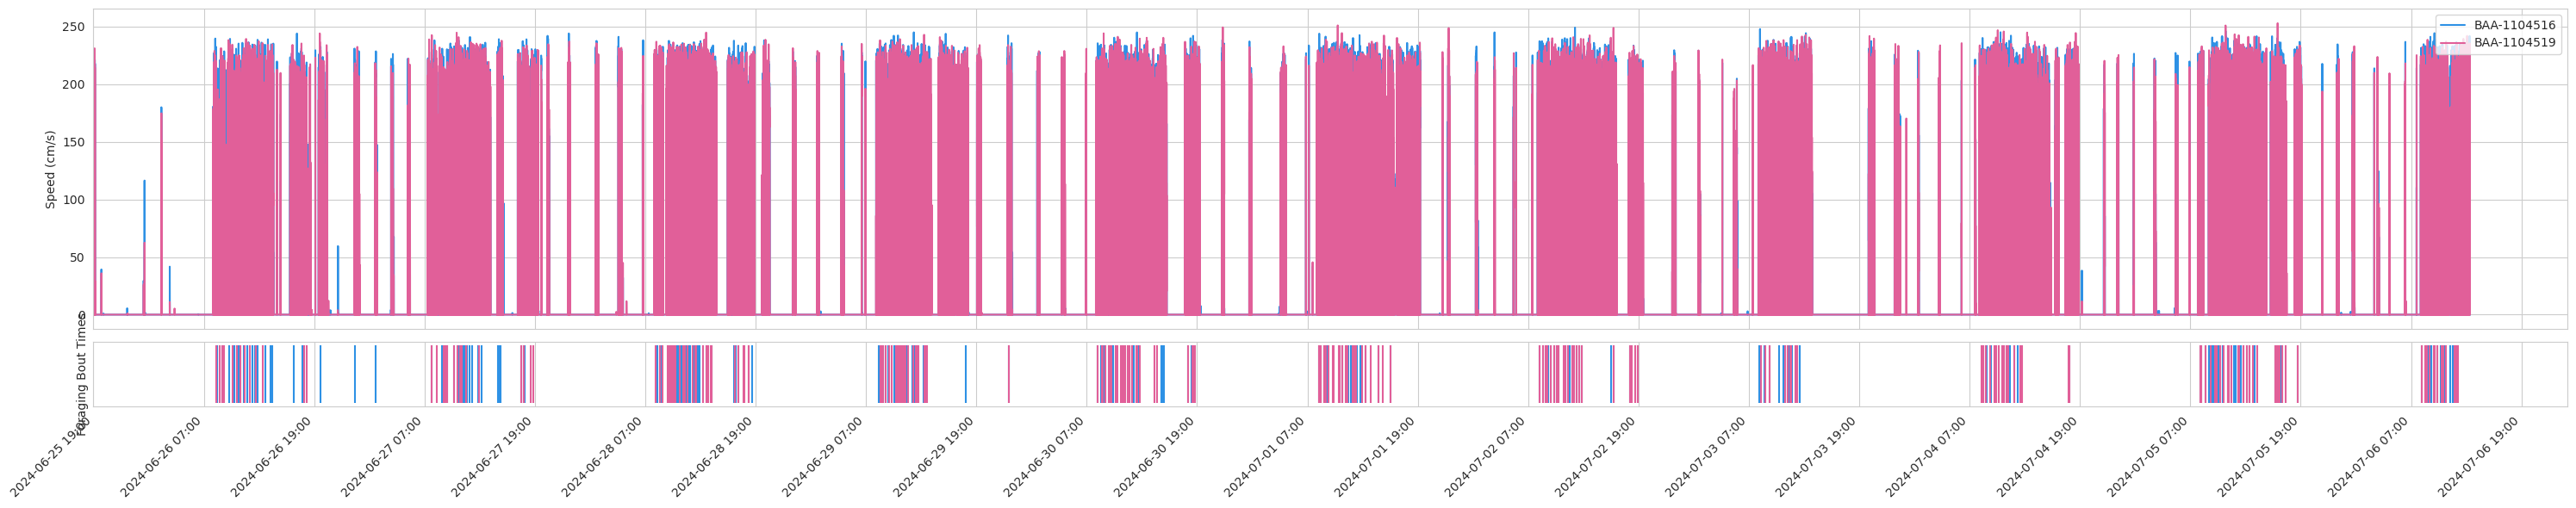

In [193]:
sns.set_style("whitegrid")

# Create figure and axes
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(30, 6), height_ratios=[5, 1], sharex=True)

# Plot speed data
sns.lineplot(data=baa16_period_df, x="time", y="speed", ax=ax1, color=subject_colors[0], label="BAA-1104516")
sns.lineplot(data=baa19_period_df, x="time", y="speed", ax=ax1, color=subject_colors[1], label="BAA-1104519")

# Plot foraging bout data
ax2.vlines(baa16_foraging_df["start"], 0, 1, color=subject_colors[0], label="BAA-1104516")
ax2.vlines(baa19_foraging_df["start"], 0, 1, color=subject_colors[1], label="BAA-1104519")

# Set x-axis ticks
tick_interval = pd.Timedelta(hours=12)
tick_vals = pd.date_range(start=start, end=end, freq=tick_interval)
ax2.set_xticks(tick_vals)

# Format x-axis labels
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d %H:%M'))

# Rotate and align x-axis labels
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right')

# Set labels and titles
ax1.set_ylabel("Speed (cm/s)")
ax2.set_ylabel("Foraging Bout Times")
ax2.set_yticks([])  # Remove y-ticks for foraging bout subplot

# Set x-axis limits
ax1.set_xlim(start, end)
ax2.set_xlim(start, end)

# Adjust layout
plt.tight_layout()

# Add legends
ax1.legend(loc='upper right')
# ax2.legend(loc='upper right')

In [ ]:
# Use plotly `make_subplots` and specify figure size to be 30,6
# fig = make_subplots(rows=2, cols=1, shared_xaxes=True, vertical_spacing=0.04, row_heights=[0.833, 0.167])

# # Speed traces
# fig.add_trace(
#     go.Scatter(
#         x=baa16_period_df["time"].iloc[0:800000],
#         y=baa16_period_df["speed"].iloc[0:800000],
#         mode="lines",
#         line=dict(color=subject_colors[0]),
#         name="BAA-1104516",
#     ),
#     row=1,
#     col=1,
# )
# fig.add_trace(
#     go.Scatter(
#         x=baa19_period_df["time"].iloc[0:800000],
#         y=baa19_period_df["speed"].iloc[0:800000],
#         mode="lines",
#         line=dict(color=subject_colors[1]),
#         name="BAA-1104519",
#     ),
#     row=1,
#     col=1
# )

# # Foraging bout traces
# fig.add_trace(
#     go.Scatter(
#         x=baa16_foraging_df["start"],
#         y=([0] * len(baa16_foraging_df)),
#         mode="markers",
#         marker=dict(symbol="line-ns", size=10, color=subject_colors[0]),
#         name="BAA-1104516",
#     ),
#     row=2,
#     col=1,
# )
# fig.add_trace(
#     go.Scatter(
#         x=baa19_foraging_df["start"],
#         y=([0] * len(baa19_foraging_df)),
#         mode="markers",
#         marker=dict(symbol="line-ns", size=10, color=subject_colors[1]),
#         name="BAA-1104519",
#     ),
#     row=2,
#     col=1,
# )

# fig.update_layout(height=300, width=1500)

### Heatmaps by light vs. dark for each animal

In [278]:
# Create a column for light vs. dark
baa19_period_df["phase"] = pd.cut(
    baa19_period_df["time"].dt.hour,
    bins=[-1, 7, 19, 24],
    labels=["light", "dark", "light"],
    include_lowest=True,
    ordered=False,
    right=False,
)




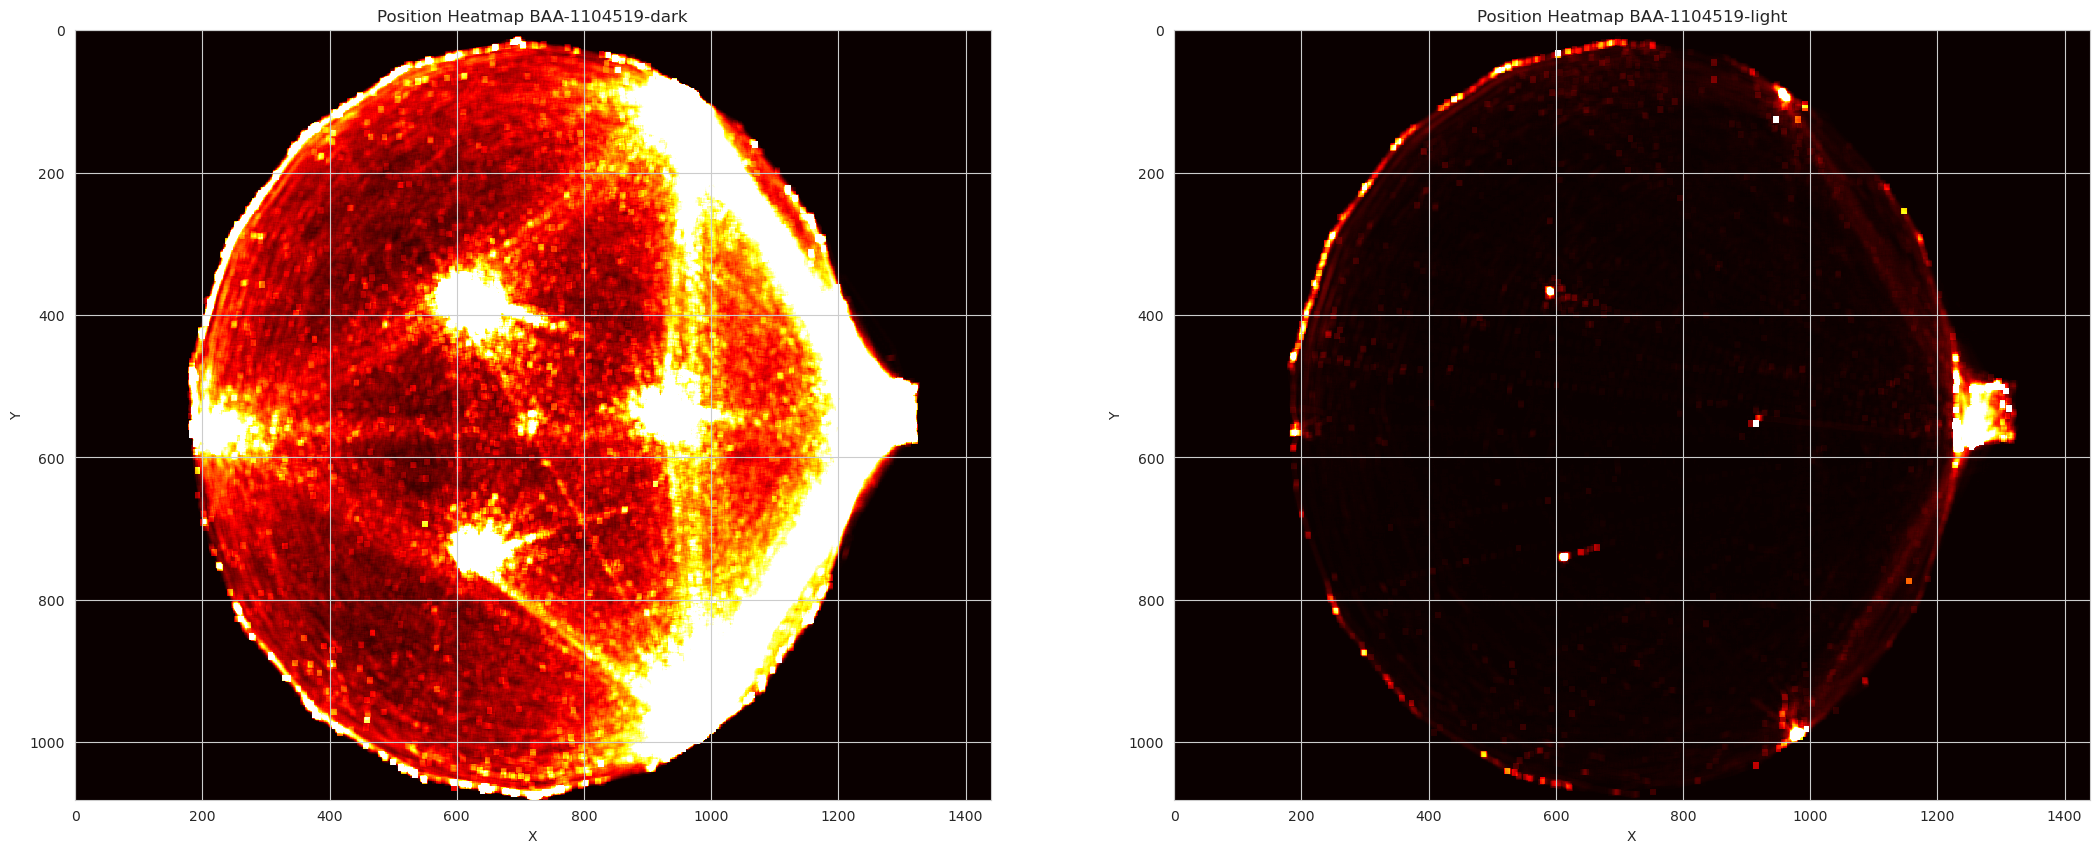

In [279]:
grouped = baa19_period_df.groupby("phase")
fig19_heatmap_phase, axes19_heatmap_phase = plt.subplots(1, 2, figsize=(26, 10))
max_x, may_y = 1439, 1079
win_sz = 9
kernel = np.ones((win_sz, win_sz)) / win_sz**2
for i, (phase, phase_df) in enumerate(grouped):
    subj_phase = phase_df.iloc[0]["identity"] + "-" + phase

    img_grid = np.zeros((max_x + 1, max_y + 1))
    points, counts = np.unique(phase_df[["x", "y"]].values, return_counts=True, axis=0)
    for point, count in zip(points, counts):
        img_grid[point[0], point[1]] = count
    img_grid /= sum(counts)  # normalize
    img_grid_p = np.pad(
        img_grid, win_sz // 2, mode="edge"
    )  # pad for full output from convolution
    img_grid_smooth = conv2d(img_grid_p, kernel)

    ax = axes19_heatmap_phase[i]
    ax.imshow(
        img_grid_smooth.T,
        vmin=0,
        vmax=(img_grid_smooth.max() / 2000),
        cmap="hot",
        interpolation="nearest",
        aspect="auto",
    )
    ax.set_title(f"Position Heatmap {subj_phase}")
    ax.set_xlabel("X")
    ax.set_ylabel("Y")

    pickle.dump(img_grid_smooth, open(f"pos_heatmap_{subj_phase}.pkl", "wb"))

In [244]:
baa16_period_df

,time,identity,identity_likelihood,part,x,y,part_likelihood,speed,phase
0,2024-06-25 19:00:00.000,BAA-1104516,0.910790,centroid,1259,576,0.954380,0.0,light
1,2024-06-25 19:00:00.100,BAA-1104516,0.920534,centroid,1259,576,0.963509,0.0,light
2,2024-06-25 19:00:00.200,BAA-1104516,0.937243,centroid,1259,576,0.963963,0.0,light
3,2024-06-25 19:00:00.300,BAA-1104516,0.936828,centroid,1259,576,0.971014,0.0,light
4,2024-06-25 19:00:00.400,BAA-1104516,0.925400,centroid,1259,576,0.963958,0.0,light
...,...,...,...,...,...,...,...,...,...
9302223,2024-07-06 13:23:42.300,BAA-1104516,0.983295,centroid,967,981,0.964390,0.0,dark
9302224,2024-07-06 13:23:42.400,BAA-1104516,0.983295,centroid,966,982,0.964390,0.0,dark
9302225,2024-07-06 13:23:42.500,BAA-1104516,0.983295,centroid,966,982,0.964390,0.0,dark
9302226,2024-07-06 13:23:42.600,BAA-1104516,0.943136,centroid,966,983,0.791335,0.0,dark


#### (Per-patch, per-subject) Wheel distance spun, with pellet deliveries underneath

In [61]:
pellet_df = (BlockSubjectAnalysis.Patch() & key & f"block_start >= '{start}'" & f"block_start <= '{end}'").fetch(format="frame")

In [62]:
pellet_df = pellet_df.reset_index()
pellet_df = pellet_df[pellet_df["patch_name"] != "PatchDummy1"].reset_index().drop(columns=["index"])
baa16_pellet_df = pellet_df[pellet_df["subject_name"] == "BAA-1104516"]
baa19_pellet_df = pellet_df[pellet_df["subject_name"] == "BAA-1104519"]

In [233]:
display(pellet_df)

,experiment_name,block_start,patch_name,subject_name,in_patch_timestamps,in_patch_time,pellet_count,pellet_timestamps,patch_threshold,wheel_cumsum_distance_travelled
0,social0.3-aeon3,2024-06-25 21:21:33.032,Patch1,BAA-1104516,"[2024-06-25T21:21:33.032000065, 2024-06-25T21:...",0.0,0,[],[],"[-0.0, 0.003068148840715157, 0.003068148840715..."
1,social0.3-aeon3,2024-06-25 21:21:33.032,Patch1,BAA-1104519,"[2024-06-25T21:21:33.032000065, 2024-06-25T21:...",0.0,0,[],[],"[0.0, 0.0, -0.004602223261072735, 0.0, 0.0, 0...."
2,social0.3-aeon3,2024-06-25 21:21:33.032,Patch2,BAA-1104516,"[2024-06-25T21:21:33.032000065, 2024-06-25T21:...",0.0,0,[],[],"[-0.0, -0.00767037210178767, -0.00767037210178..."
3,social0.3-aeon3,2024-06-25 21:21:33.032,Patch2,BAA-1104519,"[2024-06-25T21:21:33.032000065, 2024-06-25T21:...",0.0,0,[],[],"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
4,social0.3-aeon3,2024-06-25 21:21:33.032,Patch3,BAA-1104516,"[2024-06-25T21:21:33.032000065, 2024-06-25T21:...",0.0,0,[],[],"[-0.0, 0.0015340744203573564, 0.00153407442035..."
...,...,...,...,...,...,...,...,...,...,...
604,social0.3-aeon3,2024-07-06 12:32:53.028,Patch1,BAA-1104519,"[2024-07-06T12:32:53.029983997, 2024-07-06T12:...",38.5,0,[],[],"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, -0.0015340..."
605,social0.3-aeon3,2024-07-06 12:32:53.028,Patch2,BAA-1104516,"[2024-07-06T12:32:53.029983997, 2024-07-06T12:...",298.5,10,"[2024-07-06T12:42:45.307424068, 2024-07-06T12:...","[1027.5817372313309, 124.22595365747834, 145.2...","[-0.0, -0.006136297681431202, -0.0030681488407..."
606,social0.3-aeon3,2024-07-06 12:32:53.028,Patch2,BAA-1104519,"[2024-07-06T12:32:53.029983997, 2024-07-06T12:...",350.7,14,"[2024-07-06T12:36:27.556640148, 2024-07-06T12:...","[370.2259194172944, 198.1893755952369, 308.553...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.00306814..."
607,social0.3-aeon3,2024-07-06 12:32:53.028,Patch3,BAA-1104516,"[2024-07-06T12:32:53.029983997, 2024-07-06T12:...",42.1,0,[],[],"[-0.0, -0.0015340744203573564, -0.003068148840..."


In [235]:
grouped = pellet_df.groupby(["patch_name", "subject_name"])
wheel_data = []
pellet_data = []

def create_wheel_ts(row):
    return pd.date_range(
        start=row["block_start"],
        periods=len(row["wheel_cumsum_distance_travelled"]),
        freq="100ms",
    )

for (patch, subject), group in grouped:
    group["wheel_ts"] = group.apply(create_wheel_ts, axis=1)
    wheel_dist_diffs = group["wheel_cumsum_distance_travelled"].apply(lambda x: np.diff(x, prepend=0))
    total_dist = np.cumsum(np.concatenate(wheel_dist_diffs.values))
    all_ts = np.concatenate(group["wheel_ts"].dropna().values)
    wheel_data.append(
        {
            "patch_name": patch,
            "subject_name": subject,
            "distance": total_dist,
            "wheel_ts": all_ts
        }
    )

    # Process pellet data
    pellet_ts = group["pellet_timestamps"].values
    pellet_ts = np.concatenate([ts for ts in pellet_ts if ts is not None and ts.size > 0])
    pellet_data.append(
        {
            "patch_name": patch,
            "subject_name": subject,
            "pellet_ts": pellet_ts
        }
    )
pellet_data = pd.DataFrame(pellet_data)
pellet_data["pellet_ts"] = pellet_data["pellet_ts"].apply(lambda x: x[x <= end])
wheel_data = pd.DataFrame(wheel_data)

In [236]:
display(pellet_data), display(wheel_data)

,patch_name,subject_name,pellet_ts
0,Patch1,BAA-1104516,"[2024-06-26T09:09:35.617663860, 2024-06-26T09:..."
1,Patch1,BAA-1104519,"[2024-06-26T09:51:31.514400005, 2024-06-26T13:..."
2,Patch2,BAA-1104516,"[2024-06-26T08:32:52.184959888, 2024-06-26T08:..."
3,Patch2,BAA-1104519,"[2024-06-26T08:40:33.494112015, 2024-06-26T08:..."
4,Patch3,BAA-1104516,"[2024-06-26T08:38:42.413248062, 2024-06-26T08:..."
5,Patch3,BAA-1104519,"[2024-06-26T08:22:04.668447971, 2024-06-26T08:..."


,patch_name,subject_name,distance,wheel_ts
0,Patch1,BAA-1104516,"[-0.0, 0.003068148840715157, 0.003068148840715...","[2024-06-25T21:21:33.032000000, 2024-06-25T21:..."
1,Patch1,BAA-1104519,"[0.0, 0.0, -0.004602223261072735, 0.0, 0.0, 0....","[2024-06-25T21:21:33.032000000, 2024-06-25T21:..."
2,Patch2,BAA-1104516,"[-0.0, -0.00767037210178767, -0.00767037210178...","[2024-06-25T21:21:33.032000000, 2024-06-25T21:..."
3,Patch2,BAA-1104519,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[2024-06-25T21:21:33.032000000, 2024-06-25T21:..."
4,Patch3,BAA-1104516,"[-0.0, 0.0015340744203573564, 0.00153407442035...","[2024-06-25T21:21:33.032000000, 2024-06-25T21:..."
5,Patch3,BAA-1104519,"[0.0, 0.0, -0.0015340744203573564, 0.001534074...","[2024-06-25T21:21:33.032000000, 2024-06-25T21:..."


(None, None)

In [237]:
patch_colors_dict = {
    "Patch1": patch_colors[0],
    "Patch2": patch_colors[1],
    "Patch3": patch_colors[2],
}
subject_linestyles_dict = {
    "BAA-1104516": "-",
    "BAA-1104519": "--",
}

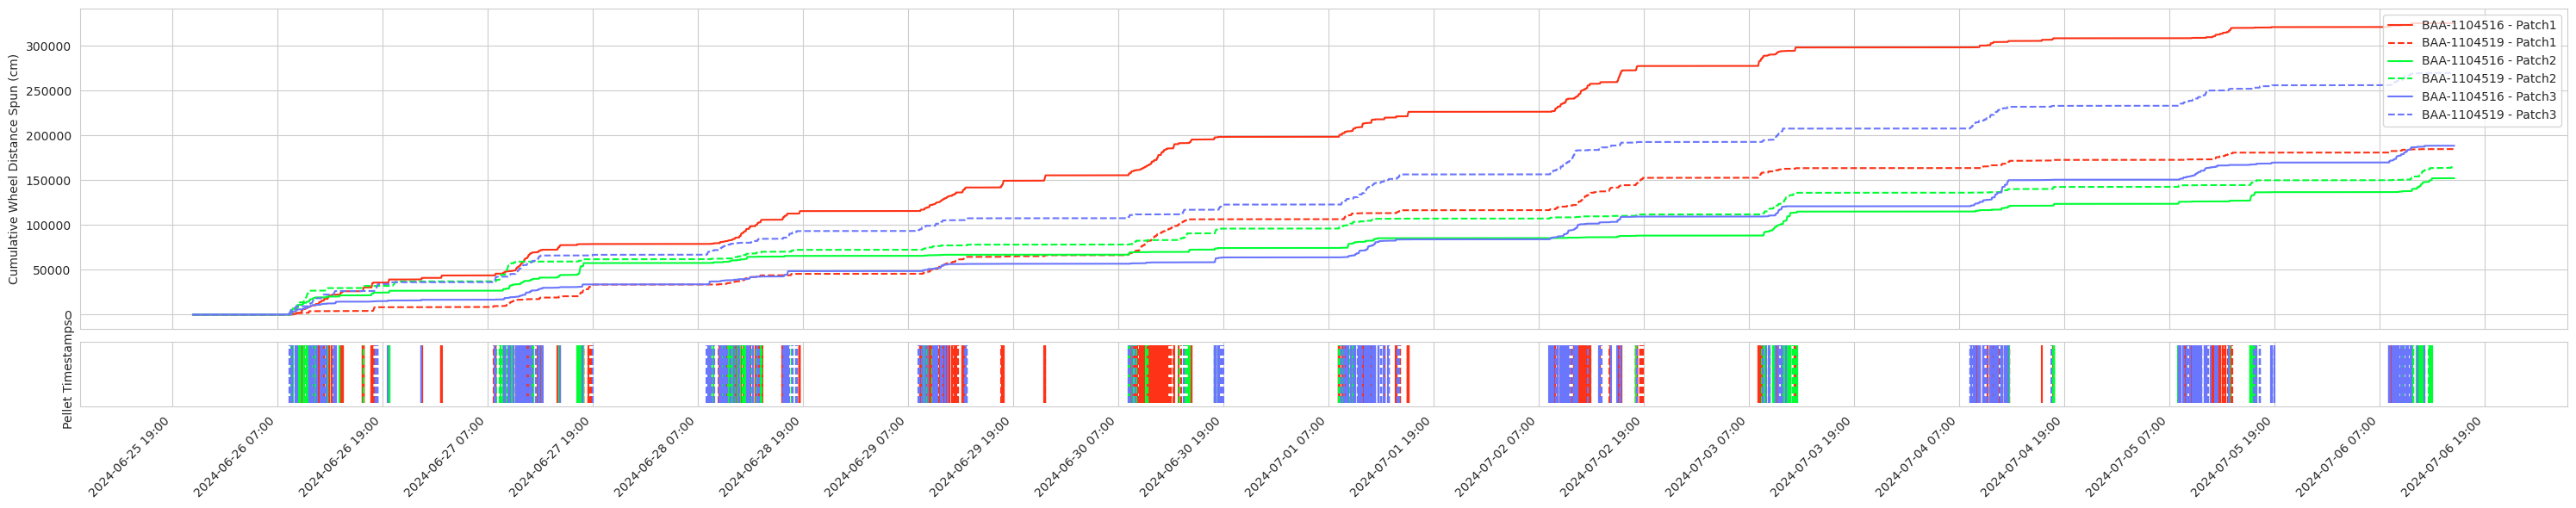

In [239]:
# Create the plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(30, 6), height_ratios=[5, 1], sharex=True)

# Plot wheel data
i = 0
for _, row in wheel_data.iterrows():
    ax1.plot(
        row["wheel_ts"],
        row["distance"], 
        color=patch_colors_dict[row["patch_name"]], 
        linestyle=subject_linestyles_dict[row["subject_name"]],
        label=f"{row['subject_name']} - {row['patch_name']}"
    )

# Plot pellet data
for _, row in pellet_data.iterrows():
    ax2.vlines(
        row["pellet_ts"],
        0,
        1,
        color=patch_colors_dict[row["patch_name"]],
        linestyle=subject_linestyles_dict[row["subject_name"]],
        label=f"{row['subject_name']} - {row['patch_name']}",
    )

# Set x-axis ticks
tick_interval = pd.Timedelta(hours=12)
tick_vals = pd.date_range(start=start, end=end, freq=tick_interval)
ax2.set_xticks(tick_vals)

# Format x-axis labels
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d %H:%M"))

# Rotate and align x-axis labels
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha="right")

# Set labels and title
ax1.set_ylabel("Cumulative Wheel Distance Spun (cm)")
ax2.set_ylabel("Pellet Timestamps")
ax2.set_yticks([])  # Remove y-ticks for foraging bout subplot

# fig.suptitle('Wheel Distance and Pellet Timestamps by Patch and Subject')

# Set legend
# handles, labels = ax1.get_legend_handles_labels()
# by_label = dict(zip(labels, handles))
# ax1.legend(by_label.values(), by_label.keys(), loc="upper right", bbox_to_anchor=(1, 1))
ax1.legend(loc="upper right")

plt.tight_layout()

In [240]:
fig.savefig("./figures/wheel_spun_cumsum_plus_pellet_deliveries.svg", dpi=600)

#### Mouse weight

In [156]:
block_analysis_subject_df = (
    BlockAnalysis.Subject & key & f"block_start >= '{start}'" & f"block_start <= '{end}'"
).fetch(format="frame")

In [158]:
block_analysis_subject_df.reset_index(inplace=True)

In [159]:
display(block_analysis_subject_df)

,experiment_name,block_start,subject_name,weights,weight_timestamps,position_x,position_y,position_likelihood,position_timestamps,cumsum_distance_travelled
0,social0.3-aeon3,2024-06-25 21:21:33.032000,BAA-1104516,[],[],"[1253.8324, 1253.8304, 1253.8262, 1253.8318, 1...","[571.01013, 571.0072, 571.0197, 571.0032, 571....","[0.66819054, 0.6769169, 0.67593914, 0.67511487...","[2024-06-25T21:21:33.059999943, 2024-06-25T21:...","[0.0, 0.003521046167445302, 0.0167425909809429..."
1,social0.3-aeon3,2024-06-25 21:21:33.032000,BAA-1104519,[],[],"[1253.8651, 1253.866, 1253.8801, 1253.8704, 12...","[568.64716, 568.65967, 568.667, 568.65436, 568...","[0.7721759, 0.76067525, 0.7585366, 0.76289874,...","[2024-06-25T21:21:33.239999771, 2024-06-25T21:...","[0.0, 0.012541350871870242, 0.0284835654395601..."
2,social0.3-aeon3,2024-06-25 23:50:06.005984,BAA-1104516,[],[],"[1259.0227, 1259.0203, 1259.0336, 1259.0369, 1...","[571.5248, 571.519, 571.52, 571.50653, 571.518...","[0.62796605, 0.6200204, 0.62838125, 0.62515384...","[2024-06-25T23:50:06.059999943, 2024-06-25T23:...","[0.0, 0.006291359902370698, 0.0196374194346955..."
3,social0.3-aeon3,2024-06-26 00:00:01.008000,BAA-1104516,[],[],"[1256.2616, 1256.2705, 1256.268, 1256.2642, 12...","[571.3644, 571.3689, 571.3717, 571.37384, 571....","[0.76437646, 0.74306357, 0.75435513, 0.7852513...","[2024-06-26T00:00:01.019999981, 2024-06-26T00:...","[0.0, 0.009990394270317443, 0.0137922525472699..."
4,social0.3-aeon3,2024-06-26 00:00:01.008000,BAA-1104519,[],[],"[1253.9253, 1253.843, 1253.8079, 1253.8275, 12...","[576.4341, 576.5139, 579.124, 579.0401, 579.05...","[0.33258358, 0.34780622, 0.30007717, 0.3160295...","[2024-06-26T00:08:28.199999809, 2024-06-26T00:...","[0.0, 0.11464163712929122, 2.7249858128350586,..."
...,...,...,...,...,...,...,...,...,...,...
198,social0.3-aeon3,2024-07-06 08:33:16.008000,BAA-1104519,"[28.1000004, 28.1000004, 28.1000004, 28.100000...","[2024-07-06T08:47:54.340000153, 2024-07-06T08:...","[589.9441, 589.9589, 589.9471, 589.9751, 589.9...","[368.59088, 368.59668, 368.5849, 368.60217, 36...","[1.1063564, 1.100164, 1.0698593, 1.0912104, 1....","[2024-07-06T08:33:16.039999962, 2024-07-06T08:...","[0.0, 0.015924679330444814, 0.0326270253932085..."
199,social0.3-aeon3,2024-07-06 10:30:48.005984,BAA-1104516,"[22.7000008, 22.7000008, 22.3999996, 22.399999...","[2024-07-06T10:36:41.559999943, 2024-07-06T10:...","[590.0811, 594.7955, 594.80896, 592.7769, 590....","[365.7616, 368.2916, 368.38034, 368.17502, 365...","[0.86685777, 0.70963806, 0.70752007, 0.6814732...","[2024-07-06T10:30:48.199999809, 2024-07-06T10:...","[0.0, 5.3503309532193155, 5.440095326598125, 7..."
200,social0.3-aeon3,2024-07-06 10:30:48.005984,BAA-1104519,"[26.9449997, 28.4482918, 28.9682922, 28.968292...","[2024-07-06T10:39:29.639999866, 2024-07-06T11:...","[592.6019, 981.89856, 592.6448, 981.8908, 592....","[366.04578, 987.3012, 366.09784, 987.296, 368....","[0.84200144, 0.47123334, 0.78895277, 0.5132317...","[2024-07-06T10:30:48.019999981, 2024-07-06T10:...","[0.0, 733.1508567465052, 1466.234845338447, 21..."
201,social0.3-aeon3,2024-07-06 12:32:53.028000,BAA-1104516,"[24.7000008, 24.7000008, 24.7000008, 24.700000...","[2024-07-06T12:44:22.059999943, 2024-07-06T12:...","[965.91003, 965.8681, 965.8124, 965.78345, 965...","[93.65518, 93.671745, 93.70379, 93.75215, 93.7...","[0.19837092, 0.20877534, 0.24852999, 0.2916628...","[2024-07-06T12:32:53.059999943, 2024-07-06T12:...","[0.0, 0.045084013472695875, 0.1093651899344888..."


In [160]:
weight_df = block_analysis_subject_df[["block_start", "subject_name", "weights", "weight_timestamps"]]

In [161]:
display(weight_df)

,block_start,subject_name,weights,weight_timestamps
0,2024-06-25 21:21:33.032000,BAA-1104516,[],[]
1,2024-06-25 21:21:33.032000,BAA-1104519,[],[]
2,2024-06-25 23:50:06.005984,BAA-1104516,[],[]
3,2024-06-26 00:00:01.008000,BAA-1104516,[],[]
4,2024-06-26 00:00:01.008000,BAA-1104519,[],[]
...,...,...,...,...
198,2024-07-06 08:33:16.008000,BAA-1104519,"[28.1000004, 28.1000004, 28.1000004, 28.100000...","[2024-07-06T08:47:54.340000153, 2024-07-06T08:..."
199,2024-07-06 10:30:48.005984,BAA-1104516,"[22.7000008, 22.7000008, 22.3999996, 22.399999...","[2024-07-06T10:36:41.559999943, 2024-07-06T10:..."
200,2024-07-06 10:30:48.005984,BAA-1104519,"[26.9449997, 28.4482918, 28.9682922, 28.968292...","[2024-07-06T10:39:29.639999866, 2024-07-06T11:..."
201,2024-07-06 12:32:53.028000,BAA-1104516,"[24.7000008, 24.7000008, 24.7000008, 24.700000...","[2024-07-06T12:44:22.059999943, 2024-07-06T12:..."


In [180]:
weight_ts = group["weight_timestamps"].values
all_ts = np.concatenate([ts for ts in weight_ts if ts is not None and ts.size > 0])

In [169]:
grouped = weight_df.groupby("subject_name")
weight_data = []

for subject, group in grouped:
    all_weights = np.concatenate(group["weights"].dropna().values)
    weight_ts = group["weight_timestamps"].values
    all_ts = np.concatenate([ts for ts in weight_ts if ts is not None and ts.size > 0])
    weight_data.append(
        {
            "subject_name": subject,
            "weights": all_weights,
            "weight_ts": all_ts
        }
    )

weight_data = pd.DataFrame(weight_data)

In [170]:
display(weight_data)

,subject_name,weights,weight_ts
0,BAA-1104516,"[24.8999996, 24.8999996, 24.8999996, 24.899999...","[1719389460340000153, 1719389467420000076, 171..."
1,BAA-1104519,"[28.7999992, 28.7999992, 28.7999992, 28.799999...","[1719392972199999809, 1719392972300000191, 171..."


In [ ]:
# Searborn plot weights over weight_ts, colored by subject
fig, ax = plt.subplots(figsize=(30, 6))

weight_data_long = pd.DataFrame(
    {
        "subject_name": weight_data["subject_name"].repeat(weight_data["weights"].str.len()),
        "weight": weight_data["weights"].explode(),
        "weight_ts": weight_data["weight_ts"].explode(),
    }
)

sns.lineplot(
    data=weight_data_long,
    x="weight_ts",
    y="weight",
    hue="subject_name",
    ax=ax,
    palette=subject_colors
)

# Set x-axis ticks
tick_interval = pd.Timedelta(hours=12)
tick_vals = pd.date_range(start=start, end=end, freq=tick_interval)
ax.set_xticks(tick_vals)

# Format x-axis labels
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d %H:%M"))

# Rotate and align x-axis labels
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha="right")

# Set labels and title
ax.set_ylabel("Weight(g)")

### Bar plots

#### Distance traveled per hour, by light vs. dark, averaged across both mice, with std. err bar

In [280]:
display(centroid_df)
display(baa16_period_df)

,identity,identity_likelihood,part,x,y,part_likelihood
time,,,,,,
2024-06-25 19:00:00.000,BAA-1104516,0.910790,centroid,1259,576,0.954380
2024-06-25 19:00:00.100,BAA-1104516,0.920534,centroid,1259,576,0.963509
2024-06-25 19:00:00.200,BAA-1104516,0.937243,centroid,1259,576,0.963963
2024-06-25 19:00:00.300,BAA-1104516,0.936828,centroid,1259,576,0.971014
2024-06-25 19:00:00.400,BAA-1104516,0.925400,centroid,1259,576,0.963958
...,...,...,...,...,...,...
2024-07-06 13:23:42.200,BAA-1104516,0.983295,centroid,960,1000,0.964390
2024-07-06 13:23:42.400,BAA-1104519,0.920344,centroid,963,1021,0.915946
2024-07-06 13:23:42.500,BAA-1104519,0.987104,centroid,957,1035,0.383165


,time,identity,identity_likelihood,part,x,y,part_likelihood,speed,phase
0,2024-06-25 19:00:00.000,BAA-1104516,0.910790,centroid,1259,576,0.954380,0.0,light
1,2024-06-25 19:00:00.100,BAA-1104516,0.920534,centroid,1259,576,0.963509,0.0,light
2,2024-06-25 19:00:00.200,BAA-1104516,0.937243,centroid,1259,576,0.963963,0.0,light
3,2024-06-25 19:00:00.300,BAA-1104516,0.936828,centroid,1259,576,0.971014,0.0,light
4,2024-06-25 19:00:00.400,BAA-1104516,0.925400,centroid,1259,576,0.963958,0.0,light
...,...,...,...,...,...,...,...,...,...
9302223,2024-07-06 13:23:42.300,BAA-1104516,0.983295,centroid,967,981,0.964390,0.0,dark
9302224,2024-07-06 13:23:42.400,BAA-1104516,0.983295,centroid,966,982,0.964390,0.0,dark
9302225,2024-07-06 13:23:42.500,BAA-1104516,0.983295,centroid,966,982,0.964390,0.0,dark
9302226,2024-07-06 13:23:42.600,BAA-1104516,0.943136,centroid,966,983,0.791335,0.0,dark


In [308]:
# Calculate distance traveled
baa16_period_df["distance"] = np.linalg.norm(baa16_period_df[["x", "y"]].diff().fillna(0), axis=1) * cm2px

# Set distances greater than 40 to 0
baa16_period_df["distance"] = np.where(baa16_period_df["distance"] > 40, 0, baa16_period_df["distance"])

baa16_period_df["hour_group"] = baa16_period_df["time"].dt.floor("H")
hourly_distances = baa16_period_df.groupby("hour_group")["distance"].sum().reset_index()
hourly_distances["distance"] = hourly_distances["distance"] / 10
display(hourly_distances)

# Create 'is_light' grouping
hourly_distances["is_light"] = (hourly_distances["hour_group"].dt.hour >= 19) | (
    hourly_distances["hour_group"].dt.hour < 7
)

# Describe
baa16_light_hourly_dist = hourly_distances[hourly_distances["is_light"] == True]["distance"].describe()
baa16_dark_hourly_dist = hourly_distances[hourly_distances["is_light"] == False]["distance"].describe()
display(baa16_light_hourly_dist)
display(baa16_dark_hourly_dist)

,hour_group,distance
0,2024-06-25 19:00:00,1782.412005
1,2024-06-25 20:00:00,123.886173
2,2024-06-25 21:00:00,70.200000
3,2024-06-25 22:00:00,707.911413
4,2024-06-25 23:00:00,143.593911
...,...,...
254,2024-07-06 09:00:00,29111.805444
255,2024-07-06 10:00:00,26100.775658
256,2024-07-06 11:00:00,19226.688115
257,2024-07-06 12:00:00,24588.667026


count      132.000000
mean      1597.962100
std       2775.712839
min          0.000000
25%        166.024651
50%        368.602534
75%       1816.520246
max      22114.522423
Name: distance, dtype: float64

count      127.000000
mean     16861.569039
std      10316.559988
min          0.000000
25%       9199.121648
50%      17768.920214
75%      26206.041964
max      34144.610682
Name: distance, dtype: float64

In [310]:
# Calculate distance traveled
baa19_period_df["distance"] = np.linalg.norm(baa19_period_df[["x", "y"]].diff().fillna(0), axis=1) * cm2px

# Set distances greater than 40 to 0
baa19_period_df["distance"] = np.where(baa19_period_df["distance"] > 40, 0, baa19_period_df["distance"])

baa19_period_df["hour_group"] = baa19_period_df["time"].dt.floor("H")
hourly_distances = baa19_period_df.groupby("hour_group")["distance"].sum().reset_index()
hourly_distances["distance"] = hourly_distances["distance"] / 10
display(hourly_distances)

# Create 'is_light' grouping
hourly_distances["is_light"] = (
    (hourly_distances["hour_group"].dt.hour >= 19)
    | (hourly_distances["hour_group"].dt.hour < 7)
)

# Describe
baa19_light_hourly_dist = hourly_distances[hourly_distances["is_light"] == True]["distance"].describe()
baa19_dark_hourly_dist = hourly_distances[hourly_distances["is_light"] == False]["distance"].describe()
display(baa19_light_hourly_dist)
display(baa19_dark_hourly_dist)

,hour_group,distance
0,2024-06-25 19:00:00,1436.289807
1,2024-06-25 20:00:00,22.775475
2,2024-06-25 21:00:00,0.000000
3,2024-06-25 22:00:00,390.319718
4,2024-06-25 23:00:00,0.000000
...,...,...
254,2024-07-06 09:00:00,27415.319411
255,2024-07-06 10:00:00,26836.190408
256,2024-07-06 11:00:00,17123.107118
257,2024-07-06 12:00:00,29780.904319


count      132.000000
mean      1851.792256
std       3171.365289
min          0.000000
25%         10.270000
50%        167.024427
75%       2871.686176
max      17996.742440
Name: distance, dtype: float64

count      127.000000
mean     18492.598547
std      10090.747141
min          0.000000
25%      11553.495216
50%      21570.262091
75%      26318.548284
max      34656.896248
Name: distance, dtype: float64

Text(0.5, 0, 'Distance travelled per hour (m)')

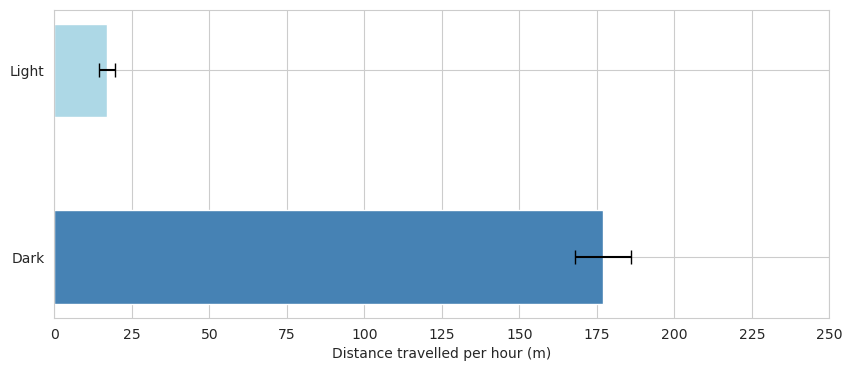

In [321]:
mean_dark = 177
std_err_dark = 101
mean_light = 17
std_err_light = 30
std_err_mean_light = std_err_light / np.sqrt(len(hourly_distances[hourly_distances["is_light"] == True]))
std_err_mean_dark = std_err_dark / np.sqrt(len(hourly_distances[hourly_distances["is_light"] == False]))

# Create the figure and axis
fig, ax = plt.subplots(figsize=(10, 4))

# Define categories and their positions
categories = ["Light", "Dark"]
y_pos = np.arange(len(categories))

# Create horizontal bars
ax.barh(
    y_pos,
    [mean_light, mean_dark],
    align="center",
    height=0.5,
    color=["#ADD8E6", "#4682B4"],
)  # Light blue for Light, Steel blue for Dark

# Add error bars
ax.errorbar(
    x=[mean_light, mean_dark],
    y=y_pos,
    xerr=[std_err_mean_light, std_err_mean_dark],
    fmt="none",
    ecolor="black",
    capsize=5,
)

# Customize the plot
ax.set_yticks(y_pos)
ax.set_yticklabels(categories)
ax.invert_yaxis()  # Labels read top-to-bottom
ax.set_xticks(np.arange(0, 251, 25))
ax.set_xlabel("Distance travelled per hour (m)")

In [322]:
fig.savefig("./figures/summary_phase_distance_travelled_per_hour.svg", dpi=600)

In [ ]:

# Create the figure and axis
fig, ax = plt.subplots(figsize=(10, 4))

# Define categories and their positions
categories = ["Light", "Dark"]
y_pos = np.arange(len(categories))

# Create horizontal bars
ax.barh(
    y_pos,
    [mean_light, mean_dark],
    align="center",
    height=0.5,
    color=["#ADD8E6", "#4682B4"],
)  # Light blue for Light, Steel blue for Dark

# Add error bars
ax.errorbar(
    x=[mean_light, mean_dark],
    y=y_pos,
    xerr=[std_err_light, std_err_dark],
    fmt="none",
    ecolor="black",
    capsize=5,
)

# Customize the plot
ax.set_yticks(y_pos)
ax.set_yticklabels(categories)
ax.invert_yaxis()  # Labels read top-to-bottom
ax.set_xticks(np.arange(0, 251, 25))
ax.set_xlabel("Distance travelled per hour (m)")

#### Foraging bouts per hour, by light vs. dark, averaged across both mice, with std. err bar

In [323]:
display(all_foraging_bouts)

,start,end,n_pellets,cum_wheel_dist,subject
0,2024-06-26 08:19:28.617983818,2024-06-26 08:44:57.117983818,9,10094.185141,BAA-1104519
1,2024-06-26 08:24:54.117983818,2024-06-26 08:47:03.717984200,13,10320.547026,BAA-1104516
2,2024-06-26 08:45:06.217984200,2024-06-26 08:51:35.917984009,4,1900.547925,BAA-1104519
3,2024-06-26 09:02:09.515999793,2024-06-26 09:12:55.915999889,3,4036.594682,BAA-1104519
4,2024-06-26 09:02:11.616000175,2024-06-26 09:12:55.915999889,5,4478.635158,BAA-1104516
...,...,...,...,...,...
6,2024-07-06 11:43:20.605984211,2024-07-06 11:47:59.405983925,5,2123.898422,BAA-1104516
7,2024-07-06 11:50:48.205984116,2024-07-06 11:54:08.105984211,6,1406.249203,BAA-1104519
8,2024-07-06 11:54:08.705984116,2024-07-06 11:56:11.505983829,3,412.253353,BAA-1104519
9,2024-07-06 11:56:33.305984020,2024-07-06 12:00:49.803999901,4,1622.851307,BAA-1104516


In [324]:
baa19_foraging_bouts = all_foraging_bouts[all_foraging_bouts["subject"] == "BAA-1104519"]
baa19_foraging_bouts["hour_group"] = baa19_foraging_bouts["start"].dt.floor("H")
hourly_bouts = baa19_foraging_bouts.groupby("hour_group").size().reset_index()
hourly_bouts["is_light"] = (hourly_bouts["hour_group"].dt.hour >= 19) | (

/tmp/ipykernel_3278629/1187071144.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [325]:
hourly_bouts

,hour_group,0
0,2024-06-26 08:00:00,2
1,2024-06-26 09:00:00,2
2,2024-06-26 10:00:00,3
3,2024-06-26 11:00:00,1
4,2024-06-26 12:00:00,2
...,...,...
77,2024-07-06 08:00:00,4
78,2024-07-06 09:00:00,3
79,2024-07-06 10:00:00,3
80,2024-07-06 11:00:00,3


#### Pellet delivery rate per hour, by light vs. dark, stacked by patches, averaged across both mice, with std. err bar

#### Wheel distance spun per hour, by light vs. dark, stacked by patches, averaged across both mice, with std. err bar

---